# 8. Baseline Machine Learning Model

## Business Objective

The objective of this notebook is to build a baseline credit risk prediction model using Logistic Regression. This model serves as the initial benchmark for evaluating future machine learning models. The notebook covers data preparation, model training, evaluation using multiple performance metrics, and business interpretation of the results.

By the end of this notebook, we will have a reproducible baseline model that can be compared against more advanced algorithms in subsequent notebooks.

## 8.1 Import Required Libraries

In this section, we import all the required Python libraries for building the baseline credit risk prediction model.

The notebook uses:

- Pandas and NumPy for data manipulation
- Matplotlib and Seaborn for data visualization
- Scikit-learn for data preprocessing, model training, and model evaluation
- Logistic Regression as the baseline classification algorithm

These libraries provide a complete machine learning pipeline, from data preparation to model evaluation.

In [5]:
# =============================================================================
# Data Manipulation
# =============================================================================
import pandas as pd
import numpy as np

# =============================================================================
# Data Visualization
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns


# ===========================================================================
# Machine Learning
# =============================================================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# =============================================================================
# Model Saving
# =============================================================================
import joblib

# =============================================================================
# Display Settings
# =============================================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# =============================================================================
# Ignore Warnings
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

# 8.2 Load Engineered Dataset

In this section, we load the engineered dataset created in the previous notebook. The dataset contains cleaned and transformed features that are ready for machine learning model development.

After loading the data, we verify its dimensions, inspect the first few records, and review the data types to ensure that all features have been correctly processed before model training.

In [6]:
# ==========================================
# Load Engineered Dataset
# ==========================================

# Load the processed dataset
df = pd.read_csv("../data/processed/application_train_engineered.csv")

# Display dataset dimensions
print(f"Dataset Shape: {df.shape}")

# Display first five rows
display(df.head())

# Display data types
display(df.dtypes)

Dataset Shape: (307511, 146)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,REGISTRATION_YEARS,ID_PUBLISH_YEARS,PHONE_CHANGE_YEARS,EMPLOYMENT_YEARS,HAS_EMPLOYMENT_INFO,INCOME_PER_EMPLOYMENT_YEAR,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,INCOME_PER_FAMILY_MEMBER,INCOME_PER_CHILD,EMPLOYMENT_AGE_RATIO,EMPLOYMENT_CATEGORY,CREDIT_TERM,LOAN_GOODS_RATIO,AVG_EXT_SOURCE,EXT_RISK_CATEGORY,AGE_CATEGORY,ID_CHANGE_YEARS,INCOME_EMPLOYMENT_SCORE,CREDIT_EMPLOYMENT_SCORE,INCOME_EXT_SOURCE_SCORE,CREDIT_EXT_SOURCE_SCORE
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637.00,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00,25.90,9.99,5.80,3.11,1.74,1,116379.31,2.01,0.12,16.46,202500.00,202500.00,0.07,0-2 Years,16.46,1.16,0.16,Very High Risk,26-35,5.81,13604.25,27315.82,32761.89,65782.24
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188.00,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,0.54,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00

SK_ID_CURR                   int64
TARGET                       int64
NAME_CONTRACT_TYPE             str
CODE_GENDER                    str
FLAG_OWN_CAR                   str
                            ...   
ID_CHANGE_YEARS            float64
INCOME_EMPLOYMENT_SCORE    float64
CREDIT_EMPLOYMENT_SCORE    float64
INCOME_EXT_SOURCE_SCORE    float64
CREDIT_EXT_SOURCE_SCORE    float64
Length: 146, dtype: object

## 8.3 Select Features and Target

Before training the machine learning model, the dataset is divided into predictor variables (features) and the target variable.

- **Features (X):** All applicant characteristics used to predict the probability of loan default.
- **Target (y):** The `TARGET` column, where:
  - **0** = Client repaid the loan successfully.
  - **1** = Client experienced payment difficulties (default).

The unique customer identifier (`SK_ID_CURR`) is excluded from the feature set because it does not provide predictive information and may introduce unnecessary noise into the model.

In [7]:
# ==========================================
# 8.3 Select Features and Target
# ==========================================

# Define the target variable
y = df["TARGET"]

# Define the feature matrix by removing the target and identifier columns
X = df.drop(columns=["TARGET", "SK_ID_CURR"])

# Display dataset summary
print("=" * 60)
print("Feature Selection Summary")
print("=" * 60)

print(f"Total Observations : {X.shape[0]:,}")
print(f"Total Features     : {X.shape[1]}")
print(f"Target Shape       : {y.shape}")

print("\nTarget Class Distribution")
display(y.value_counts().rename_axis("TARGET").to_frame("Count"))

print("\nTarget Class Distribution (%)")
display(
    (y.value_counts(normalize=True) * 100)
    .round(2)
    .rename_axis("TARGET")
    .to_frame("Percentage")
)

Feature Selection Summary
Total Observations : 307,511
Total Features     : 144
Target Shape       : (307511,)

Target Class Distribution


,Count
TARGET,
0,282686
1,24825



Target Class Distribution (%)


,Percentage
TARGET,
0,91.93
1,8.07


### Business Interpretation

The dataset is highly imbalanced, with approximately **92%** of applicants successfully repaying their loans and only **8%** experiencing payment difficulties.

Such class imbalance is common in credit risk datasets because loan defaults are relatively rare events. As a result, relying solely on **accuracy** can produce misleading conclusions. Therefore, additional evaluation metrics such as **Precision**, **Recall**, **F1-Score**, and **ROC-AUC** will be used to assess model performance more effectively.

## 8.4 Train-Test Split

To evaluate the model fairly, the dataset is divided into training and testing subsets.

- **Training Set (80%)**: Used to train the machine learning model.
- **Testing Set (20%)**: Used to evaluate the model on unseen data.

Since the target variable is highly imbalanced, **stratified sampling** is used to ensure that the proportion of default and non-default cases remains consistent in both datasets.

A fixed `random_state` is also specified to make the results reproducible.

In [8]:
# ==========================================
# 8.4 Train-Test Split
# ==========================================

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Display dataset dimensions
print("=" * 60)
print("Train-Test Split Summary")
print("=" * 60)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

print(f"\nTraining Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")

Train-Test Split Summary
Training Features : (246008, 144)
Testing Features  : (61503, 144)

Training Target   : (246008,)
Testing Target    : (61503,)


In [9]:
# Save test dataset
joblib.dump(X_test, "../models/X_test.pkl")
joblib.dump(y_test, "../models/y_test.pkl")

print("Test dataset saved successfully.")

Test dataset saved successfully.


### Business Interpretation

The dataset has been divided into training and testing subsets using an **80:20 split**. The training dataset will be used to learn patterns associated with loan default, while the testing dataset will provide an unbiased assessment of model performance.

Stratified sampling ensures that both datasets maintain the original distribution of the target classes, which is particularly important for imbalanced credit risk datasets. This helps produce reliable and representative performance metrics.

## 8.5 Data Preprocessing

Machine learning algorithms require numerical inputs with minimal missing values. Therefore, the dataset undergoes a preprocessing pipeline before model training.

The preprocessing steps include:

- Separating numerical and categorical features.
- Imputing missing numerical values using the median.
- Imputing missing categorical values using the most frequent category.
- Applying One-Hot Encoding to categorical variables.
- Standardizing numerical features using StandardScaler.

A `ColumnTransformer` is used to apply these transformations efficiently, while a Scikit-learn `Pipeline` ensures that preprocessing is consistently applied to both training and testing datasets.

In [6]:
# ==========================================
# Additional Preprocessing Libraries
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

## 8.5.1 Separate Numerical and Categorical Features

In [7]:
# ==========================================
# Separate Numerical and Categorical Features
# ==========================================

# Numerical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("=" * 60)
print("Feature Type Summary")
print("=" * 60)

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")
print(f"Total Features       : {len(numerical_features) + len(categorical_features)}")

Feature Type Summary
Numerical Features   : 125
Categorical Features : 19
Total Features       : 144


### Missing Value Analysis

Before applying imputation, the missing values in numerical and categorical features are examined.

Understanding the extent of missing data helps validate the preprocessing strategy and provides insight into data quality.

In [8]:
# ==========================================
# Missing Value Analysis
# ==========================================

# Missing values in numerical features
num_missing = (
    X_train[numerical_features]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

num_missing = num_missing[num_missing > 0]

print("Top Numerical Features with Missing Values")
display(num_missing.head(10))

# Missing values in categorical features
cat_missing = (
    X_train[categorical_features]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

cat_missing = cat_missing[cat_missing > 0]

print("Categorical Features with Missing Values")
display(cat_missing)

Top Numerical Features with Missing Values


COMMONAREA_AVG              171811
COMMONAREA_MODE             171811
COMMONAREA_MEDI             171811
NONLIVINGAPARTMENTS_AVG     170729
NONLIVINGAPARTMENTS_MODE    170729
NONLIVINGAPARTMENTS_MEDI    170729
LIVINGAPARTMENTS_MEDI       168119
LIVINGAPARTMENTS_MODE       168119
LIVINGAPARTMENTS_AVG        168119
FLOORSMIN_MEDI              166921
dtype: int64

Categorical Features with Missing Values


EMPLOYMENT_CATEGORY    44145
dtype: int64

In [9]:
# ==========================================
# Numerical Preprocessing Pipeline
# ==========================================

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [10]:
# ==========================================
# Categorical Preprocessing Pipeline
# ==========================================

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

## 8.5.2 Missing Value Imputation

Missing numerical values are replaced using the **median**, while missing categorical values are replaced using the **most frequent category**.

The median is robust to extreme values, making it suitable for financial variables, whereas the mode preserves the most representative category for categorical features.

In [11]:
# ==========================================
# Column Transformer
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 8.5.3  One-Hot Encoding

Categorical variables are transformed into binary indicator variables using One-Hot Encoding.

This transformation enables the Logistic Regression model to process categorical information while avoiding ordinal relationships between categories.

## 8.5.4  Feature Scaling

Numerical features are standardized using the StandardScaler.

Standardization ensures that all numerical variables have comparable scales, improving the convergence and stability of the Logistic Regression algorithm.

### Preprocessing Pipeline Summary

The complete preprocessing workflow has been assembled using a Scikit-learn `ColumnTransformer`.

The pipeline performs the following operations automatically:

1. Imputes missing numerical values using the median.
2. Standardizes numerical features.
3. Imputes missing categorical values using the most frequent category.
4. Applies One-Hot Encoding to categorical variables.

This preprocessing pipeline will be reused throughout the project to ensure consistent transformations during model training and evaluation.

## 8.6 Train Baseline Logistic Regression

Logistic Regression is used as the baseline classification model for predicting loan default.

The preprocessing pipeline created in the previous section is combined with the Logistic Regression algorithm into a single Scikit-learn Pipeline. This ensures that all preprocessing steps are automatically applied before model training, preventing data leakage and maintaining a consistent workflow.

The trained model will serve as a benchmark for comparing more advanced machine learning algorithms in subsequent notebooks.

In [12]:
# ==========================================
# 8.6 Train Baseline Logistic Regression
# ==========================================

# Create the complete machine learning pipeline
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]
)

# Train the model
print("Training Logistic Regression model...")

baseline_model.fit(X_train, y_train)

print("Model training completed successfully.")

Training Logistic Regression model...


Model training completed successfully.


### Business Interpretation

The Logistic Regression model has been trained using the preprocessed training dataset. As the baseline model, it establishes a reference level of predictive performance for identifying applicants who are likely to default.

The preprocessing and model training have been integrated into a single pipeline, ensuring that all transformations are applied consistently during both training and future predictions. This approach minimizes the risk of data leakage and follows industry best practices for machine learning model development.

## 8.7 Model Predictions

After training the Logistic Regression model, predictions are generated using the unseen test dataset.

Two types of predictions are obtained:

- **Predicted Class:** Indicates whether an applicant is classified as a non-default (0) or default (1).
- **Predicted Probability:** Represents the estimated probability that an applicant will default.

The predicted probabilities will be used in subsequent sections to evaluate model performance using metrics such as ROC-AUC and Precision-Recall curves.

In [13]:
# ==========================================
# 8.7 Model Predictions
# ==========================================

# Generate predicted class labels
y_pred = baseline_model.predict(X_test)

# Generate predicted probabilities for the positive class
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Prediction Summary")
print("=" * 60)

print(f"Total Test Samples      : {len(y_test):,}")
print(f"Predicted Class Shape   : {y_pred.shape}")
print(f"Predicted Probability Shape : {y_prob.shape}")

print("\nFirst 10 Predicted Classes:")
print(y_pred[:10])

print("\nFirst 10 Predicted Probabilities:")
print(np.round(y_prob[:10], 4))

Prediction Summary
Total Test Samples      : 61,503
Predicted Class Shape   : (61503,)
Predicted Probability Shape : (61503,)

First 10 Predicted Classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 Predicted Probabilities:
[0.0539 0.0397 0.2357 0.109  0.1034 0.141  0.0092 0.0067 0.3836 0.0667]


### Business Interpretation

The trained Logistic Regression model has generated predictions for all applicants in the testing dataset.

The predicted class identifies whether an applicant is expected to repay the loan or default, while the predicted probability provides a quantitative estimate of default risk. Financial institutions typically use these probabilities to rank applicants by risk level and support informed lending decisions.

## 8.8 Model Performance Evaluation

The performance of the baseline Logistic Regression model is evaluated using multiple classification metrics.

Since credit default prediction is an imbalanced classification problem, relying solely on accuracy can be misleading. Therefore, additional metrics such as Precision, Recall, F1-Score, ROC-AUC, and Precision-Recall Curve are used to provide a comprehensive assessment of the model's predictive performance.

The evaluation also includes a Confusion Matrix and Classification Report to better understand the model's strengths and limitations.

In [14]:
# ==========================================
# Model Performance Metrics
# ==========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

performance["Score"] = performance["Score"].round(4)

display(performance)

,Metric,Score
0,Accuracy,0.92
1,Precision,0.58
2,Recall,0.01
3,F1-Score,0.02
4,ROC-AUC,0.75


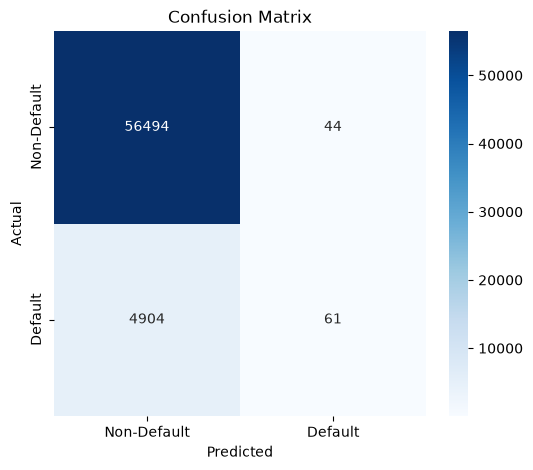

In [15]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.58      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.75      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



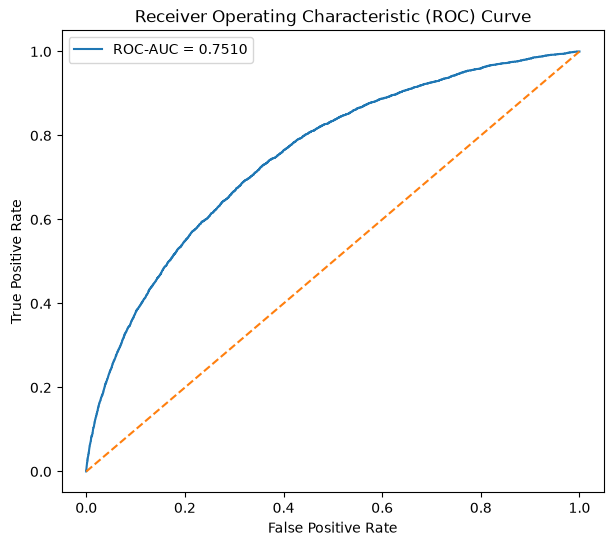

In [17]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.legend()

plt.show()

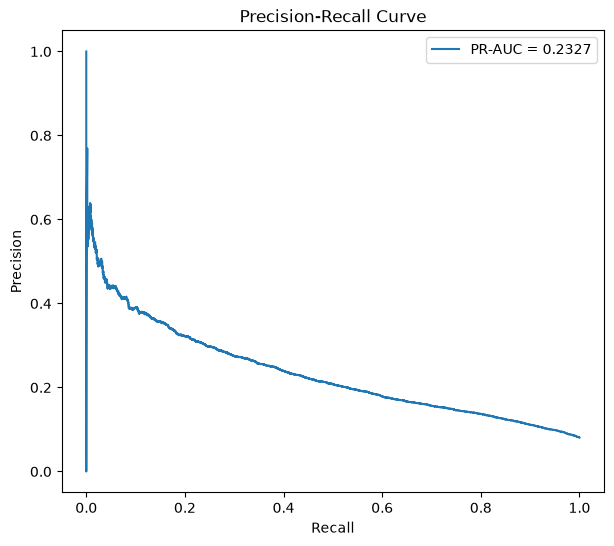

In [18]:
# ==========================================
# Precision-Recall Curve
# ==========================================

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

### Business Interpretation

The baseline Logistic Regression model achieved an overall accuracy of **92%** and a ROC-AUC score of **0.751**, indicating a reasonable ability to distinguish between defaulting and non-defaulting applicants.

However, the model identified only **61** of the **4,965** actual default cases, resulting in a recall of approximately **1%**. This indicates that although the model makes relatively few false default predictions (precision ≈ **58%**), it fails to detect the vast majority of borrowers who eventually default.

This behaviour is expected because the dataset is highly imbalanced, with only about **8%** of applicants belonging to the default class. Using the default classification threshold of **0.50** causes the model to favour the majority class.

Therefore, while Logistic Regression provides a useful baseline, additional techniques such as class weighting, threshold tuning, resampling methods (e.g., SMOTE), or more advanced machine learning algorithms will be explored in the following notebooks to improve the identification of high-risk applicants.

## 8.9 Feature Importance (Logistic Regression Coefficients)

Logistic Regression estimates a coefficient for each feature used during model training. These coefficients indicate the direction and strength of the relationship between each feature and the probability of loan default.

- **Positive coefficients** increase the likelihood of default.
- **Negative coefficients** decrease the likelihood of default.
- Features with larger absolute coefficient values have a stronger influence on the model's predictions.

Since categorical variables are transformed using One-Hot Encoding, feature names are extracted from the preprocessing pipeline before combining them with the model coefficients.

In [19]:
# ==========================================
# Extract Feature Names After Preprocessing
# ==========================================

# Numerical feature names
num_features = numerical_features

# One-hot encoded categorical feature names
cat_features = baseline_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

# Combine all feature names
feature_names = np.concatenate([num_features, cat_features])

print(f"Total Transformed Features: {len(feature_names)}")

Total Transformed Features: 279


In [20]:
# ==========================================
# Logistic Regression Coefficients
# ==========================================

coefficients = baseline_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Coefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Coefficient,Absolute Coefficient
245,ORGANIZATION_TYPE_Transport: type 3,0.56,0.56
222,ORGANIZATION_TYPE_Military,-0.52,0.52
127,CODE_GENDER_F,-0.41,0.41
278,AGE_CATEGORY_56+,-0.40,0.40
163,NAME_HOUSING_TYPE_Office apartment,-0.38,0.38
131,FLAG_OWN_CAR_Y,-0.38,0.38
4,AMT_GOODS_PRICE,-0.36,0.36
217,ORGANIZATION_TYPE_Industry: type 9,-0.30,0.30
29,EXT_SOURCE_3,-0.30,0.30
232,ORGANIZATION_TYPE_Security Ministries,-0.29,0.29


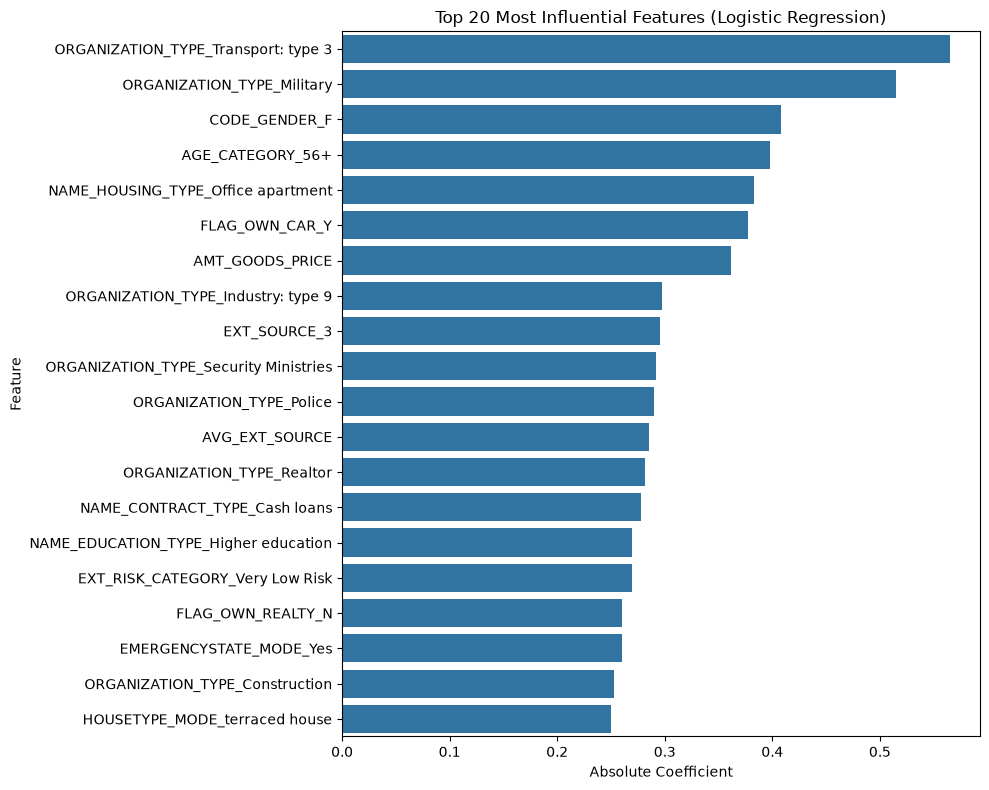

In [21]:
# ==========================================
# Top 20 Most Important Features
# ==========================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Absolute Coefficient",
    y="Feature"
)

plt.title("Top 20 Most Influential Features (Logistic Regression)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 8.10 Business Interpretation

The baseline Logistic Regression model establishes an initial benchmark for predicting loan default risk using the engineered applicant features. The model achieved an overall accuracy of **92%** and a **ROC-AUC score of 0.75**, indicating a reasonable ability to distinguish between defaulting and non-defaulting applicants.

However, the dataset is highly imbalanced, with significantly fewer default cases than non-default cases. As a result, although the model achieves high overall accuracy, it identifies only a small proportion of actual defaulters, resulting in a **very low recall (1%)**. This indicates that many high-risk applicants are still being classified as low risk when using the default probability threshold.

The feature importance analysis shows that applicant demographics, employment characteristics, external credit scores, loan-related variables, and housing information contribute most to the model's predictions. Features such as **EXT_SOURCE_3, AVG_EXT_SOURCE, AMT_GOODS_PRICE, AGE_CATEGORY, and ORGANIZATION_TYPE** demonstrate strong influence on the predicted probability of default.

From a business perspective, missing actual defaulters can lead to increased credit losses. Therefore, relying solely on this baseline Logistic Regression model would not be sufficient for production use. More advanced techniques such as class balancing, threshold optimization, and ensemble models (Random Forest, XGBoost, and LightGBM) will be evaluated in subsequent notebooks to improve default detection while maintaining acceptable predictive performance.

Overall, the baseline model provides an interpretable starting point and establishes a performance benchmark against which more sophisticated credit risk models will be compared.

## 8.11 Save Baseline Model

In this section, the trained Logistic Regression pipeline is saved using Joblib. Persisting the complete pipeline, including preprocessing and the trained classifier, enables reproducible predictions and allows the model to be reused for evaluation, deployment, and future inference without retraining.

In [22]:
# ==========================================================
# Save Baseline Logistic Regression Model
# ==========================================================

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save trained baseline model
joblib.dump(baseline_model, "../models/logistic_regression.pkl")

print("=" * 60)
print("Baseline Logistic Regression model saved successfully!")
print("=" * 60)

print("\nSaved Model:")
print("- logistic_regression.pkl")

Baseline Logistic Regression model saved successfully!

Saved Model:
- logistic_regression.pkl


### 8.11.1 Business Interpretation

Saving the trained Logistic Regression pipeline is an essential step in the machine learning lifecycle. Instead of retraining the model whenever predictions are required, the serialized pipeline can be loaded directly for evaluation, deployment, or inference. This reduces computational cost, improves reproducibility, and ensures that every new loan application undergoes the same preprocessing and prediction workflow used during model development.

In a real-world credit risk assessment system, the saved baseline model serves as a benchmark against which more advanced machine learning models can be compared. It also provides a reliable fallback model for production environments where model interpretability and simplicity are important.

### 8.11.2 Key Takeaways

- Successfully saved the trained Logistic Regression pipeline using Joblib.
- Preserved both preprocessing and classification steps within a single serialized pipeline.
- Eliminated the need to retrain the baseline model before evaluation or deployment.
- Established a reusable benchmark model for comparison with advanced machine learning algorithms.
- Improved the reproducibility and production readiness of the credit risk prediction system.

## 8.12 Summary

- Successfully trained a baseline Logistic Regression model using a Scikit-learn preprocessing pipeline.
- Applied median imputation, one-hot encoding, and feature scaling to prepare the data for modeling.
- Achieved an overall Accuracy of **92%** and a **ROC-AUC score of 0.75**, establishing a strong baseline performance benchmark.
- The model achieved high accuracy but relatively low Recall (approximately **1%**) at the default decision threshold, highlighting the impact of class imbalance in credit risk prediction.
- Feature importance analysis identified applicant demographics, employment characteristics, external credit scores, and loan-related variables as the strongest predictors of loan default.
- Successfully saved the complete baseline machine learning pipeline using **Joblib**, enabling reproducible evaluation, future inference, and deployment without retraining.